# Predicting Corporate Bankruptcy Risk for Economic Security

### AI For Good — Hackathon 5: Model Showdown

**SDG:** SDG 8 — Decent Work and Economic Growth

**Dataset:** Taiwanese Bankruptcy Prediction

The data were collected from the Taiwan Economic Journal for 1999–2009, and company bankruptcy was defined according to the business regulations of the Taiwan Stock Exchange.

source:https://archive.ics.uci.edu/dataset/572/taiwanese+bankruptcy+prediction$0

This project compares three machine-learning classifiers — K-Nearest Neighbours (KNN), Logistic Regression, and Random Forest — to predict whether a company is likely to be classified as bankrupt based on its financial indicators.

## 2. Importing Libraries

We use Python libraries for data manipulation, visualization and machine learning. Pandas is used to work with the dataset, Matplotlib is used for visualizations, and scikit-learn is used for preprocessing, model training, hyperparameter tuning and evaluation.


## 3. Loading the Dataset

The Taiwanese Bankruptcy Prediction dataset is loaded from the CSV file. Each row represents a company and the dataset contains financial indicators that can be used to predict the bankruptcy outcome.

The target variable is `Bankrupt?`.


In [8]:
!git clone https://github.com/pavitrapradeep/ai4g-portfolio-pavitra.git

import pandas as pd

file_path = "/content/ai4g-portfolio-pavitra/Term 1/Week 5/hackathon/data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

fatal: destination path 'ai4g-portfolio-pavitra' already exists and is not an empty directory.
Dataset loaded successfully!
Shape: (6819, 96)


In [9]:
# Basic information about the dataset

print("Dataset shape:", df.shape)

print("\nColumn data types:")
print(df.dtypes.value_counts())

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nBankruptcy class distribution:")
print(df["Bankrupt?"].value_counts())

print("\nBankruptcy percentages:")
print(df["Bankrupt?"].value_counts(normalize=True) * 100)

Dataset shape: (6819, 96)

Column data types:
float64    93
int64       3
Name: count, dtype: int64

Missing values:
0

Duplicate rows:
0

Bankruptcy class distribution:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Bankruptcy percentages:
Bankrupt?
0    96.77372
1     3.22628
Name: proportion, dtype: float64


In [10]:
# Show all column names

for i, column in enumerate(df.columns):
    print(i, column)

0 Bankrupt?
1  ROA(C) before interest and depreciation before interest
2  ROA(A) before interest and % after tax
3  ROA(B) before interest and depreciation after tax
4  Operating Gross Margin
5  Realized Sales Gross Margin
6  Operating Profit Rate
7  Pre-tax net Interest Rate
8  After-tax net Interest Rate
9  Non-industry income and expenditure/revenue
10  Continuous interest rate (after tax)
11  Operating Expense Rate
12  Research and development expense rate
13  Cash flow rate
14  Interest-bearing debt interest rate
15  Tax rate (A)
16  Net Value Per Share (B)
17  Net Value Per Share (A)
18  Net Value Per Share (C)
19  Persistent EPS in the Last Four Seasons
20  Cash Flow Per Share
21  Revenue Per Share (Yuan ¥)
22  Operating Profit Per Share (Yuan ¥)
23  Per Share Net profit before tax (Yuan ¥)
24  Realized Sales Gross Profit Growth Rate
25  Operating Profit Growth Rate
26  After-tax Net Profit Growth Rate
27  Regular Net Profit Growth Rate
28  Continuous Net Profit Growth Rate
29  

## 4. Exploring the Dataset

Before training any model, the dataset is explored to understand its structure and quality. This includes checking the number of rows and columns, data types, missing values, duplicate rows and the distribution of the target variable.

This step is important because understanding the data helps identify data-quality problems and potential class imbalance before modelling.

In [35]:
df.columns[:7].tolist()

['Bankrupt?',
 ' ROA(C) before interest and depreciation before interest',
 ' ROA(A) before interest and % after tax',
 ' ROA(B) before interest and depreciation after tax',
 ' Operating Gross Margin',
 ' Realized Sales Gross Margin',
 ' Operating Profit Rate']

## 5. Separating Features and Target

The target variable `Bankrupt?` is separated from the financial predictor variables.

`X` contains the 95 financial features used to make predictions, while `y` contains the bankruptcy outcome.

The target is binary:
- `0` = not bankrupt
- `1` = bankrupt

In [12]:
df[["Bankrupt?"]].head()

,Bankrupt?
0,1
1,1
2,1
3,1
4,1


### Exploration Results

The dataset contains **6,819 rows and 96 columns**. There are 95 predictor variables and one target variable, `Bankrupt?`.

The dataset contains no missing values and no duplicate rows.

There are 6,599 non-bankrupt companies and 220 bankrupt companies. Therefore, only approximately 3.23% of the observations belong to the bankruptcy class.

This represents a substantial class imbalance. A model that simply predicts every company as non-bankrupt could achieve approximately 96.77% accuracy while completely failing to identify bankrupt companies. Therefore, accuracy alone is not an appropriate primary metric for this project.

## 6. Train-Test Split

The dataset is divided into a training set and a test set using an 80/20 split.

The test set is kept separate from model training and hyperparameter tuning. It is only used for the final evaluation of the models.

Stratification is used because the dataset is highly imbalanced. This preserves approximately the same proportion of bankrupt and non-bankrupt companies in both the training and test sets.

A fixed random state of 42 is used to make the experiment reproducible.

In [13]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop("Bankrupt?", axis=1)
y = df["Bankrupt?"]

# Split the data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Training set: (5455, 95)
Test set: (1364, 95)

Training class distribution:
Bankrupt?
0    0.967736
1    0.032264
Name: proportion, dtype: float64

Test class distribution:
Bankrupt?
0    0.967742
1    0.032258
Name: proportion, dtype: float64


The resulting training set contains **5,455 observations**, while the test set contains **1,364 observations**. The bankruptcy proportion is approximately 3.23% in both sets, confirming that stratification preserved the original class distribution.

## 7. Preprocessing

All predictor variables in this dataset are numerical. Standardization is used because KNN and Logistic Regression can be affected by differences in feature scale.

StandardScaler transforms the features so that they are placed on a comparable scale.

The scaler is fitted only on the training data and then applied to the test data. This prevents information from the test set from influencing preprocessing.

For the final models, preprocessing is included inside the scikit-learn Pipeline so that scaling is also performed correctly inside cross-validation.

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

preprocessor = Pipeline([
    ("scaler", StandardScaler())
])

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

print("Training data after scaling:", X_train_scaled.shape)
print("Test data after scaling:", X_test_scaled.shape)

Training data after scaling: (5455, 95)
Test data after scaling: (1364, 95)


## 8. Baseline Model

A DummyClassifier is used as a baseline. It always predicts the majority class, which in this dataset is non-bankruptcy.

The baseline establishes the minimum level of performance that the machine-learning models should beat.

Because the dataset is highly imbalanced, the baseline can achieve high accuracy despite having zero ability to identify bankrupt companies. Therefore, precision, recall and F1 are also reported.

In [15]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

# Baseline: always predicts the majority class
baseline = DummyClassifier(strategy="most_frequent", random_state=42)

baseline.fit(X_train, y_train)

y_baseline = baseline.predict(X_test)

print("Baseline Precision:", precision_score(y_test, y_baseline))
print("Baseline Recall:", recall_score(y_test, y_baseline))
print("Baseline F1:", f1_score(y_test, y_baseline))

Baseline Precision: 0.0
Baseline Recall: 0.0
Baseline F1: 0.0


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Baseline Results

The baseline achieves approximately **96.77% accuracy**, but its precision, recall and F1 score for the bankruptcy class are all **0**.

This demonstrates why accuracy alone would be misleading for this dataset. The baseline effectively predicts that every company will remain non-bankrupt and therefore fails to identify any bankrupt companies.

In [16]:
from sklearn.metrics import accuracy_score

print("Baseline Accuracy:", accuracy_score(y_test, y_baseline))
print("Baseline Precision:", precision_score(y_test, y_baseline, zero_division=0))
print("Baseline Recall:", recall_score(y_test, y_baseline, zero_division=0))
print("Baseline F1:", f1_score(y_test, y_baseline, zero_division=0))

Baseline Accuracy: 0.967741935483871
Baseline Precision: 0.0
Baseline Recall: 0.0
Baseline F1: 0.0


## 9. Model 1 — K-Nearest Neighbours

K-Nearest Neighbours (KNN) classifies an observation based on the classes of nearby observations in the feature space.

Because KNN relies on distances between observations, feature scaling is particularly important. Therefore, StandardScaler is included inside the Pipeline.

The main hyperparameter being tuned is `n_neighbors`, which determines how many neighbouring observations are considered when making a prediction.

The values 3, 5, 7, 9, 11, 15 and 21 are evaluated using 5-fold cross-validation.

Recall is used as the scoring metric because identifying bankrupt companies is more important than simply maximizing overall accuracy.

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score

# KNN pipeline
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# Values of k we want to test
knn_param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15, 21]
}

# We use recall because missing a bankrupt company is costly
recall_scorer = make_scorer(recall_score)

# Tune KNN using 5-fold cross-validation
knn_grid = GridSearchCV(
    knn_pipeline,
    knn_param_grid,
    cv=5,
    scoring=recall_scorer,
    n_jobs=-1,
    return_train_score=True
)

knn_grid.fit(X_train, y_train)

print("Best K:", knn_grid.best_params_)
print("Best cross-validation recall:", knn_grid.best_score_)

Best K: {'knn__n_neighbors': 3}
Best cross-validation recall: 0.19380952380952382


In [18]:
# KNN tuning results

knn_results = pd.DataFrame(knn_grid.cv_results_)

knn_results[
    ["param_knn__n_neighbors", "mean_test_score", "std_test_score"]
].sort_values("param_knn__n_neighbors")

,param_knn__n_neighbors,mean_test_score,std_test_score
0,3,0.193810,0.061861
1,5,0.153651,0.039426
2,7,0.131111,0.061930
3,9,0.108254,0.046074
4,11,0.102698,0.053215
5,15,0.056984,0.018322
6,21,0.034286,0.021381


### KNN Tuning Results

The best value of `n_neighbors` was **3**, producing a mean cross-validation recall of approximately **19.38%**.

The recall decreased as the number of neighbours increased across the tested values. Therefore, K=3 was selected as the tuned KNN configuration.

### KNN Test Evaluation

The tuned KNN model is now evaluated on the held-out test set. The test set has not been used during model training or hyperparameter selection.

The evaluation includes precision, recall, F1 score and a confusion matrix.

In [19]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Predict on the untouched test set
y_knn = knn_grid.best_estimator_.predict(X_test)

print("KNN Test Results")
print("----------------")
print("Precision:", precision_score(y_test, y_knn, zero_division=0))
print("Recall:", recall_score(y_test, y_knn, zero_division=0))
print("F1:", f1_score(y_test, y_knn, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_knn, zero_division=0))

KNN Test Results
----------------
Precision: 0.42105263157894735
Recall: 0.18181818181818182
F1: 0.25396825396825395

Confusion Matrix:
[[1309   11]
 [  36    8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1320
           1       0.42      0.18      0.25        44

    accuracy                           0.97      1364
   macro avg       0.70      0.59      0.62      1364
weighted avg       0.96      0.97      0.96      1364



The tuned KNN model achieved **42.1% precision, 18.2% recall and 25.4% F1** on the test set.

It correctly identified 8 of the 44 bankrupt companies in the test set. However, it missed 36 bankrupt companies, showing that KNN has limited ability to detect the minority bankruptcy class in this experiment.

## 10. Model 2 — Logistic Regression

Logistic Regression is used as a linear classification model. It estimates the probability that an observation belongs to the bankruptcy class.

StandardScaler is included in the Pipeline because the financial indicators have different numerical scales.

The main hyperparameter being tuned is `C`, which controls the strength of regularization. Several values of C are tested using the same 5-fold cross-validation procedure and recall metric used for KNN.

Using the same cross-validation strategy and scoring metric makes the comparison between models fair.

In [20]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression pipeline
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

# Values of C to test
logistic_param_grid = {
    "logistic__C": [0.001, 0.01, 0.1, 1, 10, 100]
}

# Tune using the same 5-fold CV and recall metric
logistic_grid = GridSearchCV(
    logistic_pipeline,
    logistic_param_grid,
    cv=5,
    scoring=recall_scorer,
    n_jobs=-1,
    return_train_score=True
)

logistic_grid.fit(X_train, y_train)

print("Best C:", logistic_grid.best_params_)
print("Best cross-validation recall:", logistic_grid.best_score_)

Best C: {'logistic__C': 100}
Best cross-validation recall: 0.25650793650793646


### Logistic Regression Tuning Results

The best value of `C` was **100**, producing a mean cross-validation recall of approximately **25.65%**.

The cross-validation results were used to select the hyperparameter before evaluating the model on the held-out test set.

In [21]:
logistic_results = pd.DataFrame(logistic_grid.cv_results_)

logistic_results[
    ["param_logistic__C", "mean_test_score", "std_test_score"]
].sort_values("param_logistic__C")


,param_logistic__C,mean_test_score,std_test_score
0,0.001,0.051270,0.021552
1,0.010,0.130952,0.034928
2,0.100,0.193810,0.059163
3,1.000,0.211111,0.086475
4,10.000,0.233968,0.100197
5,100.000,0.256508,0.085829


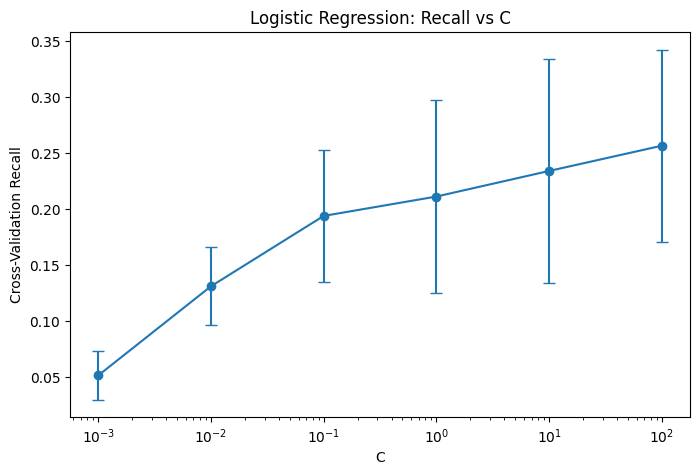

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.errorbar(
    logistic_results["param_logistic__C"].astype(float),
    logistic_results["mean_test_score"],
    yerr=logistic_results["std_test_score"],
    marker="o",
    capsize=4
)

plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Cross-Validation Recall")
plt.title("Logistic Regression: Recall vs C")
plt.show()

### Logistic Regression Test Evaluation

The tuned Logistic Regression model is evaluated once on the untouched test set.

In [23]:
y_logistic = logistic_grid.best_estimator_.predict(X_test)

print("Logistic Regression Test Results")
print("--------------------------------")
print("Precision:", precision_score(y_test, y_logistic, zero_division=0))
print("Recall:", recall_score(y_test, y_logistic, zero_division=0))
print("F1:", f1_score(y_test, y_logistic, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_logistic))

Logistic Regression Test Results
--------------------------------
Precision: 0.3333333333333333
Recall: 0.1590909090909091
F1: 0.2153846153846154

Confusion Matrix:
[[1306   14]
 [  37    7]]


The Logistic Regression model achieved **33.3% precision, 15.9% recall and 21.5% F1** on the test set.

It correctly identified 7 of the 44 bankrupt companies. Its test recall was lower than the KNN model, despite having a higher cross-validation recall.

## 11. Model 3 — Random Forest

Random Forest is used as the third classifier because it can model nonlinear relationships between financial indicators.

The model is configured with `class_weight="balanced"` because the bankruptcy class represents only approximately 3.23% of the dataset. This gives greater importance to the minority class during training.

The hyperparameters `n_estimators`, `max_depth` and `min_samples_split` are tuned using 5-fold cross-validation and recall as the scoring metric.

The same training data and cross-validation approach used for KNN and Logistic Regression are used for Random Forest to make the comparison fair.

In [24]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest pipeline
rf_pipeline = Pipeline([
    ("rf", RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

# Hyperparameters to tune
rf_param_grid = {
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [None, 10, 20],
    "rf__min_samples_split": [2, 5]
}

# Tune using the same 5-fold CV and recall metric
rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring=recall_scorer,
    n_jobs=-1,
    return_train_score=True
)

rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best cross-validation recall:", rf_grid.best_score_)

Best parameters: {'rf__max_depth': 10, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
Best cross-validation recall: 0.449047619047619


### Random Forest Tuning Results

The best Random Forest configuration was:

- `n_estimators = 200`
- `max_depth = 10`
- `min_samples_split = 5`

This configuration achieved a mean cross-validation recall of approximately **44.90%**, which was substantially higher than the cross-validation recall of KNN and Logistic Regression.

### Random Forest Test Evaluation

The tuned Random Forest is evaluated on the held-out test set to determine how well it generalizes to unseen companies.

In [25]:
y_rf = rf_grid.best_estimator_.predict(X_test)

print("Random Forest Test Results")
print("-------------------------")
print("Precision:", precision_score(y_test, y_rf, zero_division=0))
print("Recall:", recall_score(y_test, y_rf, zero_division=0))
print("F1:", f1_score(y_test, y_rf, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_rf, zero_division=0))

Random Forest Test Results
-------------------------
Precision: 0.4098360655737705
Recall: 0.5681818181818182
F1: 0.47619047619047616

Confusion Matrix:
[[1284   36]
 [  19   25]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1320
           1       0.41      0.57      0.48        44

    accuracy                           0.96      1364
   macro avg       0.70      0.77      0.73      1364
weighted avg       0.97      0.96      0.96      1364



The Random Forest achieved **41.0% precision, 56.8% recall and 47.6% F1** on the test set.

It correctly identified **25 of the 44 bankrupt companies**, while missing 19 bankrupt companies.

Although its overall accuracy is approximately 96%, accuracy is not used as the main selection criterion because of the strong class imbalance. The much higher recall for the bankruptcy class makes Random Forest more useful for the intended financial-risk screening application.

## 12. Model Comparison

The three classifiers are compared using the same evaluation framework. The comparison includes training recall, cross-validation recall, test precision, test recall and test F1.

Training recall helps identify possible overfitting, while cross-validation recall measures performance across different training-validation folds. The final test metrics provide an evaluation on previously unseen data.

The baseline is included to show how the models perform compared with simply predicting the majority class.

In [26]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "KNN",
        "Logistic Regression",
        "Random Forest"
    ],
    "Best Parameters": [
        "Most frequent",
        str(knn_grid.best_params_),
        str(logistic_grid.best_params_),
        str(rf_grid.best_params_)
    ],
    "CV Recall": [
        0,
        knn_grid.best_score_,
        logistic_grid.best_score_,
        rf_grid.best_score_
    ],
    "Test Precision": [
        precision_score(y_test, y_baseline, zero_division=0),
        precision_score(y_test, y_knn, zero_division=0),
        precision_score(y_test, y_logistic, zero_division=0),
        precision_score(y_test, y_rf, zero_division=0)
    ],
    "Test Recall": [
        recall_score(y_test, y_baseline, zero_division=0),
        recall_score(y_test, y_knn, zero_division=0),
        recall_score(y_test, y_logistic, zero_division=0),
        recall_score(y_test, y_rf, zero_division=0)
    ],
    "Test F1": [
        f1_score(y_test, y_baseline, zero_division=0),
        f1_score(y_test, y_knn, zero_division=0),
        f1_score(y_test, y_logistic, zero_division=0),
        f1_score(y_test, y_rf, zero_division=0)
    ]
})

comparison

,Model,Best Parameters,CV Recall,Test Precision,Test Recall,Test F1
0,Baseline,Most frequent,0.000000,0.000000,0.000000,0.000000
1,KNN,{'knn__n_neighbors': 3},0.193810,0.421053,0.181818,0.253968
2,Logistic Regression,{'logistic__C': 100},0.256508,0.333333,0.159091,0.215385
3,Random Forest,"{'rf__max_depth': 10, 'rf__min_samples_split':...",0.449048,0.409836,0.568182,0.476190


In [27]:
# Training recall for each tuned model

y_knn_train = knn_grid.best_estimator_.predict(X_train)
y_logistic_train = logistic_grid.best_estimator_.predict(X_train)
y_rf_train = rf_grid.best_estimator_.predict(X_train)

print("KNN training recall:",
      recall_score(y_train, y_knn_train, zero_division=0))

print("Logistic Regression training recall:",
      recall_score(y_train, y_logistic_train, zero_division=0))

print("Random Forest training recall:",
      recall_score(y_train, y_rf_train, zero_division=0))

KNN training recall: 0.375
Logistic Regression training recall: 0.3068181818181818
Random Forest training recall: 1.0


Model Selection

Random Forest is selected as the recommended model.

It achieved the highest test recall (56.8%) and the highest test F1 score (47.6%) among the three classifiers. It identified 25 of the 44 bankrupt companies in the test set.

KNN achieved 18.2% test recall and Logistic Regression achieved 15.9% test recall.

Random Forest does show evidence of overfitting because its training recall is 100%, compared with 44.9% cross-validation recall. However, its test recall of 56.8% demonstrates useful performance on the held-out test data.

The model is therefore recommended as a decision-support tool rather than an automatic decision-maker.

In [28]:
comparison["Training Recall"] = [
    recall_score(y_train, baseline.predict(X_train), zero_division=0),
    recall_score(y_train, y_knn_train, zero_division=0),
    recall_score(y_train, y_logistic_train, zero_division=0),
    recall_score(y_train, y_rf_train, zero_division=0)
]

comparison = comparison[
    [
        "Model",
        "Best Parameters",
        "Training Recall",
        "CV Recall",
        "Test Precision",
        "Test Recall",
        "Test F1"
    ]
]

comparison

,Model,Best Parameters,Training Recall,CV Recall,Test Precision,Test Recall,Test F1
0,Baseline,Most frequent,0.000000,0.000000,0.000000,0.000000,0.000000
1,KNN,{'knn__n_neighbors': 3},0.375000,0.193810,0.421053,0.181818,0.253968
2,Logistic Regression,{'logistic__C': 100},0.306818,0.256508,0.333333,0.159091,0.215385
3,Random Forest,"{'rf__max_depth': 10, 'rf__min_samples_split':...",1.000000,0.449048,0.409836,0.568182,0.476190


## 13. Error Analysis

The errors made by the recommended Random Forest model are examined using false negatives and false positives.

A false negative occurs when a company is actually bankrupt but is predicted as non-bankrupt.

A false positive occurs when a company is actually non-bankrupt but is predicted as bankrupt.

For the intended financial-risk analyst, false negatives are more concerning because they may result in a financially distressed company not being selected for additional review.

In [29]:
# Identify Random Forest errors on the test set

error_analysis = X_test.copy()

error_analysis["Actual"] = y_test
error_analysis["Predicted"] = y_rf

# False negatives: actually bankrupt, predicted not bankrupt
false_negatives = error_analysis[
    (error_analysis["Actual"] == 1) &
    (error_analysis["Predicted"] == 0)
]

# False positives: actually not bankrupt, predicted bankrupt
false_positives = error_analysis[
    (error_analysis["Actual"] == 0) &
    (error_analysis["Predicted"] == 1)
]

print("False negatives:", len(false_negatives))
print("False positives:", len(false_positives))

print("\nFalse Negative examples:")
display(false_negatives.head())

print("\nFalse Positive examples:")
display(false_positives.head())

False negatives: 19
False positives: 36

False Negative examples:


,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),...,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability,Actual,Predicted
233,0.469458,0.539250,0.526902,0.602091,0.602077,0.999001,0.797387,0.809365,0.303452,0.781610,...,0.622374,0.602089,0.840356,0.280124,0.032780,0.569441,1,0.028018,1,0
2003,0.439624,0.485772,0.492371,0.594668,0.594668,0.998811,0.797196,0.809143,0.303516,0.781388,...,0.623623,0.594667,0.837440,0.281231,0.026719,0.564788,1,0.025012,1,0
4375,0.473212,0.544265,0.528508,0.597746,0.597789,0.998966,0.797396,0.809326,0.303543,0.781567,...,0.623280,0.597742,0.840520,0.280297,0.027616,0.567367,1,0.027471,1,0
1754,0.377955,0.366550,0.430644,0.593278,0.593616,0.998857,0.795972,0.808047,0.301282,0.780818,...,0.624460,0.593274,0.831956,0.278620,0.026737,0.564887,1,0.034808,1,0
3597,0.242822,0.119930,0.212966,0.589566,0.589566,0.998155,0.796048,0.807895,0.302884,0.780258,...,0.623812,0.589563,0.817337,0.276858,0.026791,0.565157,1,0.054710,1,0



False Positive examples:


,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),...,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability,Actual,Predicted
6037,0.466631,0.506596,0.511858,0.597832,0.597832,0.998931,0.797286,0.809218,0.303423,0.781483,...,0.624142,0.597832,0.838184,0.284718,0.026584,0.563928,1,0.019876,0,1
5230,0.419393,0.469963,0.465068,0.596715,0.596715,0.998908,0.797277,0.809213,0.303457,0.781465,...,0.623738,0.596712,0.835554,0.284980,0.026756,0.564984,1,0.019631,0,1
4990,0.385512,0.435456,0.437443,0.591483,0.591483,0.998778,0.797168,0.809133,0.303537,0.781375,...,0.623519,0.591483,0.828092,0.296665,0.026744,0.564922,1,0.014635,0,1
2589,0.459660,0.500491,0.507575,0.602063,0.602063,0.998617,0.796789,0.808491,0.303211,0.781062,...,0.622117,0.602057,0.834681,0.286074,0.026434,0.562585,1,0.018729,0,1
3540,0.160581,0.178805,0.183200,0.589732,0.589732,0.998584,0.796858,0.808815,0.303401,0.781035,...,0.623611,0.589731,0.802292,0.294702,0.026783,0.565118,1,0.015067,0,1


### Error Analysis

The Random Forest produced 19 false negatives and 36 false positives on the test set. False negatives are particularly important in this application because they represent companies that were actually bankrupt but were predicted as non-bankrupt. For a financial risk analyst, missing a financially distressed company could mean that it is not selected for additional review. False positives represent non-bankrupt companies that were flagged for review, which may use additional analyst time but is less harmful than automatically missing a financially distressed company. The model therefore prioritizes detecting the minority bankruptcy class, reflected in our use of recall as the primary cross-validation metric. The individual errors also show that the financial indicators do not perfectly separate the two classes, so predictions should support rather than replace human financial-risk assessment.

## 14. Random Forest Confusion Matrix

The confusion matrix shows how the recommended Random Forest classified the companies in the held-out test set.

The model produced:
- 1,284 true negatives
- 25 true positives
- 36 false positives
- 19 false negatives

The 25 true positives correspond to the 25 bankrupt companies correctly identified by the model.

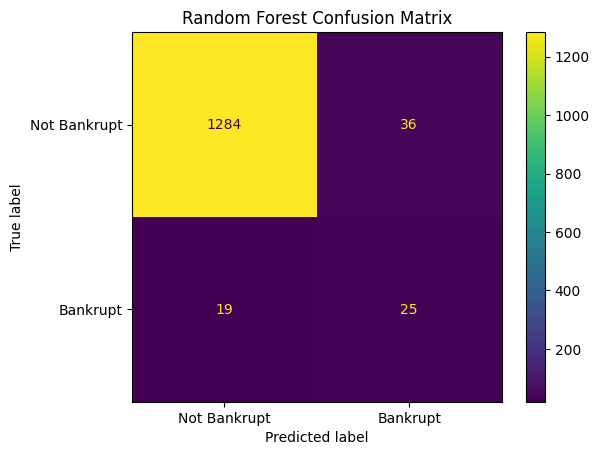

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_rf,
    display_labels=["Not Bankrupt", "Bankrupt"]
)

plt.title("Random Forest Confusion Matrix")
plt.show()

## 15. New Company Prediction

To demonstrate how the recommended Random Forest model can be applied, we provide a company's 95 financial indicators as input to the tuned model. The model uses these financial indicators to predict whether the company is classified as bankrupt or non-bankrupt and calculates the probability of each outcome.

This demonstrates how the model could be used by a financial risk analyst as an initial screening tool for assessing a company's bankruptcy risk.

In [31]:
# Create a made-up company using the financial profile
# of one company from the test set.
# We remove its actual bankruptcy label so the model treats it as a new case.

new_company = X_test.iloc[[0]].copy()

print("New company shape:", new_company.shape)
new_company.head()

New company shape: (1, 95)


,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
1244,0.503242,0.556149,0.552278,0.609399,0.609399,0.999043,0.797445,0.809349,0.303466,0.781609,...,0.805667,0.00083,0.623746,0.609399,0.841004,0.282359,0.027273,0.566736,1,0.022839


In [32]:
# Predict bankruptcy for the new company
prediction = rf_grid.best_estimator_.predict(new_company)[0]

# Get probability of each class
probabilities = rf_grid.best_estimator_.predict_proba(new_company)[0]

print("Predicted class:", prediction)
print("Probability of not bankrupt:", probabilities[0])
print("Probability of bankrupt:", probabilities[1])

Predicted class: 0
Probability of not bankrupt: 0.9904063207907479
Probability of bankrupt: 0.009593679209252226


In [33]:
if prediction == 1:
    result = "HIGHER BANKRUPTCY RISK"
else:
    result = "LOWER BANKRUPTCY RISK"

print("Prediction:", result)
print(f"Bankruptcy probability: {probabilities[1]:.2%}")

Prediction: LOWER BANKRUPTCY RISK
Bankruptcy probability: 0.96%


In [34]:
if prediction == 1:
    result = "HIGHER BANKRUPTCY RISK"
else:
    result = "LOWER BANKRUPTCY RISK"

print("FINAL MODEL PREDICTION")
print("======================")
print("Prediction:", result)
print(f"Probability of bankruptcy: {probabilities[1]:.2%}")
print(f"Probability of not bankrupt: {probabilities[0]:.2%}")

FINAL MODEL PREDICTION
Prediction: LOWER BANKRUPTCY RISK
Probability of bankruptcy: 0.96%
Probability of not bankrupt: 99.04%


The model predicted class 0 (not bankrupt), with a predicted probability of **99.04% for the non-bankrupt class** and **0.96% for the bankrupt class**.

This prediction should be treated as a risk-screening output rather than a definitive financial decision. The model is intended to support a financial risk analyst's review, not replace professional judgement.

## 16. Conclusion

This project evaluated three classification approaches for predicting corporate bankruptcy: KNN, Logistic Regression and Random Forest.

The dataset contained 6,819 companies and 95 financial predictor variables. The target was highly imbalanced, with only approximately 3.23% of companies classified as bankrupt. Because of this imbalance, recall, precision and F1 were prioritized over accuracy.

After hyperparameter tuning using 5-fold cross-validation, Random Forest produced the strongest test performance. It achieved 56.8% recall and 47.6% F1 on the held-out test set, identifying 25 of the 44 bankrupt companies.

Random Forest is therefore recommended for use as a financial-risk screening tool. However, the model still produces false negatives and shows evidence of overfitting between training and validation performance. It should therefore be used to support, rather than replace, professional financial analysis.

The project demonstrates how machine learning can support earlier identification of financially distressed companies while recognizing the limitations and risks of automated predictions. This connects the project to SDG 8 by considering the relationship between corporate financial stability, employment and economic security.